# Лабораторная работа
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Цель:** изучить способы предварительной обработки данных для последующего построения моделей машинного обучения.

В работе используется предоставленный датасет `dataset.csv` со статистическими показателями стран за 2000–2025 гг.

Материалы:
- Лекция: https://nbviewer.org/github/ugapanyuk/courses_current/blob/main/notebooks/missing/handling_missing_norm.ipynb
- Задание: https://github.com/ugapanyuk/courses_current/wiki/LAB_TMO__MISSING

## 1. Загрузка библиотек и данных

Используются `pandas` и `numpy` для работы с данными, `matplotlib` для визуализации, а также классы `scikit-learn` для импьютации, кодирования и масштабирования.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = Path('dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/dataset.csv')

data = pd.read_csv(DATA_PATH)
print('Размер датасета:', data.shape)
display(data.head())

Размер датасета: (5642, 19)


,country_code,country_name,year,gdp_usd,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,real_interest_rate_pct,unemployment_rate_pct,labor_force_total,population_total,life_expectancy,trade_pct_gdp,exports_pct_gdp,imports_pct_gdp,current_account_pct_gdp,fdi_inflows_pct_gdp,internet_users_pct,electricity_access_pct
0,ABW,Aruba,2000,"1,873,452,513.9665",7.6229,"20,681.0230",4.0440,10.9175,NaN,NaN,"90,588.0000",72.9390,145.0729,74.3860,70.6869,11.0569,-6.8287,15.4428,91.7000
1,ABW,Aruba,2001,"1,896,456,983.2402",4.1820,"20,740.1326",2.8836,15.8859,NaN,NaN,"91,439.0000",73.0440,140.3911,70.9968,69.3943,16.2809,-14.0751,17.1000,100.0000
2,ABW,Aruba,2002,"1,961,843,575.4190",-0.9450,"21,307.2483",3.3152,6.5738,NaN,NaN,"92,074.0000",73.1350,133.2308,64.5643,68.6665,-17.3435,16.9491,18.8000,100.0000
3,ABW,Aruba,2003,"2,044,111,731.8436",1.1105,"21,949.4860",3.6564,7.4246,NaN,NaN,"93,128.0000",73.2360,132.7943,62.7312,70.0631,-8.0990,7.8164,20.8000,100.0000
4,ABW,Aruba,2004,"2,254,830,726.2570",7.2937,"23,700.6320",2.5291,6.6045,NaN,NaN,"95,138.0000",73.2230,132.4309,64.6656,67.7654,12.0137,-4.6876,23.0000,100.0000


## 2. Первичный анализ данных

Проверим типы признаков, диапазон лет, количество стран и наличие пропусков.

In [2]:
print('Диапазон лет:', data['year'].min(), '—', data['year'].max())
print('Количество стран:', data['country_code'].nunique())
print()
print('Типы признаков:')
print(data.dtypes)

Диапазон лет: 2000 — 2025
Количество стран: 217

Типы признаков:
country_code                object
country_name                object
year                         int64
gdp_usd                    float64
gdp_growth_pct             float64
gdp_per_capita_usd         float64
inflation_cpi_pct          float64
real_interest_rate_pct     float64
unemployment_rate_pct      float64
labor_force_total          float64
population_total           float64
life_expectancy            float64
trade_pct_gdp              float64
exports_pct_gdp            float64
imports_pct_gdp            float64
current_account_pct_gdp    float64
fdi_inflows_pct_gdp        float64
internet_users_pct         float64
electricity_access_pct     float64
dtype: object


In [3]:
missing = pd.DataFrame({
    'Пропусков': data.isna().sum(),
    'Доля, %': data.isna().mean() * 100
})
missing = missing[missing['Пропусков'] > 0].sort_values('Доля, %', ascending=False)
display(missing.round(2))

print('Строк с хотя бы одним пропуском:', data.isna().any(axis=1).sum())
print('Доля таких строк, %:', round(data.isna().any(axis=1).mean() * 100, 2))

,Пропусков,"Доля, %"
real_interest_rate_pct,2508,44.4500
current_account_pct_gdp,1130,20.0300
trade_pct_gdp,1054,18.6800
exports_pct_gdp,1054,18.6800
imports_pct_gdp,1054,18.6800
inflation_cpi_pct,958,16.9800
unemployment_rate_pct,794,14.0700
labor_force_total,794,14.0700
internet_users_pct,742,13.1500
fdi_inflows_pct_gdp,726,12.8700


Строк с хотя бы одним пропуском: 3354
Доля таких строк, %: 59.45


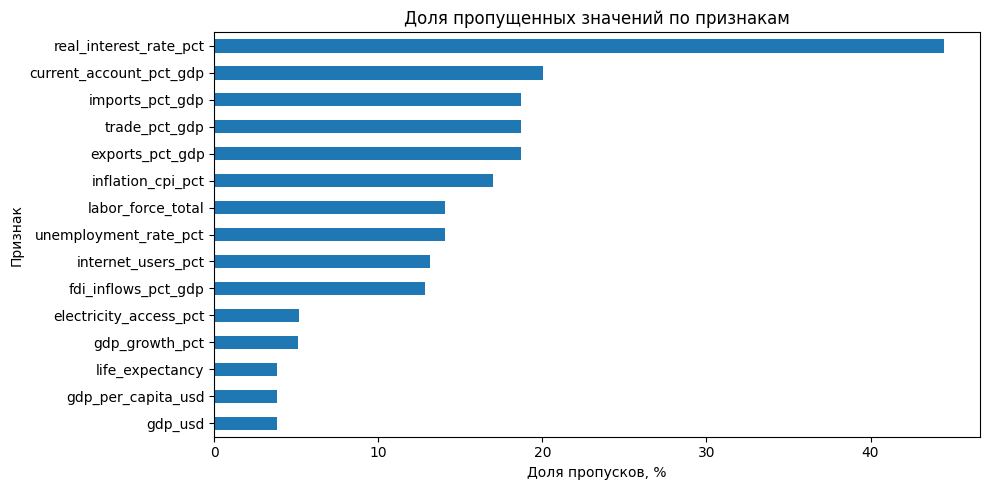

In [4]:
plt.figure(figsize=(10, 5))
missing['Доля, %'].sort_values().plot(kind='barh')
plt.xlabel('Доля пропусков, %')
plt.ylabel('Признак')
plt.title('Доля пропущенных значений по признакам')
plt.tight_layout()
plt.show()

## 3. Обработка пропусков

Признак `real_interest_rate_pct` имеет более 40% пропусков, поэтому его удалим. Для остальных числовых признаков используем **медианную импьютацию** через `SimpleImputer(strategy='median')`.

Медиана выбрана вместо среднего, поскольку экономические показатели имеют выбросы и часто сильно асимметричные распределения (например, ВВП, инфляция, прямые иностранные инвестиции).

In [5]:
# Посмотрим асимметрию признаков с пропусками
skewness = data[missing.index].skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
display(skewness.to_frame('Коэффициент асимметрии').round(3))

,Коэффициент асимметрии
inflation_cpi_pct,15.9360
fdi_inflows_pct_gdp,11.3310
gdp_usd,10.7490
labor_force_total,8.8810
current_account_pct_gdp,6.7900
gdp_per_capita_usd,3.2770
trade_pct_gdp,3.2330
exports_pct_gdp,3.0300
imports_pct_gdp,2.7350
unemployment_rate_pct,1.4710


In [6]:
# Удаляем столбец с очень большой долей пропусков
work = data.drop(columns=['real_interest_rate_pct']).copy()

# Числовые столбцы, в которых есть пропуски
num_missing_cols = [
    c for c in work.select_dtypes(include=np.number).columns
    if work[c].isna().any()
]

imputer = SimpleImputer(strategy='median')
work[num_missing_cols] = imputer.fit_transform(work[num_missing_cols])

print('Осталось пропусков после обработки:', int(work.isna().sum().sum()))
print('Размер после удаления одного признака:', work.shape)

Осталось пропусков после обработки: 0
Размер после удаления одного признака: (5642, 18)


In [7]:
# Пример результата импьютации для inflation_cpi_pct
example_col = 'inflation_cpi_pct'
missing_rows = data[example_col].isna()
example = pd.DataFrame({
    'до обработки': data.loc[missing_rows, example_col],
    'после обработки': work.loc[missing_rows, example_col]
}).head(10)
display(example)
print('Медиана, которой заполнены пропуски:', round(data[example_col].median(), 4))

,до обработки,после обработки
20,NaN,3.4676
21,NaN,3.4676
22,NaN,3.4676
23,NaN,3.4676
24,NaN,3.4676
25,NaN,3.4676
26,NaN,3.4676
27,NaN,3.4676
28,NaN,3.4676
29,NaN,3.4676


Медиана, которой заполнены пропуски: 3.4676


## 4. Кодирование категориальных признаков

В наборе данных два категориальных признака: `country_code` и `country_name`. Они фактически описывают одну и ту же сущность — страну, поэтому одновременное кодирование обоих признаков создало бы дублирование информации.

Оставим `country_code` и выполним **one-hot encoding**. Для номинального признака страны one-hot кодирование подходит лучше, чем присваивание произвольных порядковых номеров.

In [8]:
print('Категориальные признаки:')
print(work.select_dtypes(include='object').columns.tolist())
print('Пропусков в country_code:', work['country_code'].isna().sum())
print('Количество уникальных кодов стран:', work['country_code'].nunique())

Категориальные признаки:
['country_code', 'country_name']
Пропусков в country_code: 0
Количество уникальных кодов стран: 217


In [9]:
# country_name удаляем как дублирующее текстовое описание страны
work = work.drop(columns=['country_name'])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
country_encoded = ohe.fit_transform(work[['country_code']])
country_encoded_df = pd.DataFrame(
    country_encoded,
    columns=ohe.get_feature_names_out(['country_code']),
    index=work.index
)

print('Размер one-hot матрицы:', country_encoded_df.shape)
display(country_encoded_df.iloc[:5, :10])

Размер one-hot матрицы: (5642, 217)


,country_code_ABW,country_code_AFG,country_code_AGO,country_code_ALB,country_code_AND,country_code_ARE,country_code_ARG,country_code_ARM,country_code_ASM,country_code_ATG
0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Масштабирование данных

В лекции рассматриваются `MinMaxScaler` и `StandardScaler`. Сначала сравним их на признаке `gdp_per_capita_usd`.

In [10]:
scale_example = work[['gdp_per_capita_usd']].copy()

minmax = MinMaxScaler()
standard = StandardScaler()

scale_example['MinMaxScaler'] = minmax.fit_transform(scale_example[['gdp_per_capita_usd']])
scale_example['StandardScaler'] = standard.fit_transform(scale_example[['gdp_per_capita_usd']])

display(scale_example.head(10))
print()
print('Статистики после масштабирования:')
display(scale_example.describe().T[['mean', 'std', 'min', 'max']].round(4))

,gdp_per_capita_usd,MinMaxScaler,StandardScaler
0,"20,681.0230",0.0715,0.1860
1,"20,740.1326",0.0717,0.1884
2,"21,307.2483",0.0736,0.2110
3,"21,949.4860",0.0759,0.2366
4,"23,700.6320",0.0819,0.3063
5,"24,171.8371",0.0836,0.3251
6,"24,845.6585",0.0859,0.3520
7,"26,736.3089",0.0925,0.4273
8,"28,171.9094",0.0975,0.4845
9,"25,134.7712",0.0869,0.3635



Статистики после масштабирования:


,mean,std,min,max
gdp_per_capita_usd,"16,012.7307","25,097.6250",109.5938,"288,001.5749"
MinMaxScaler,0.0552,0.0872,0.0000,1.0000
StandardScaler,0.0000,1.0001,-0.6337,10.8382


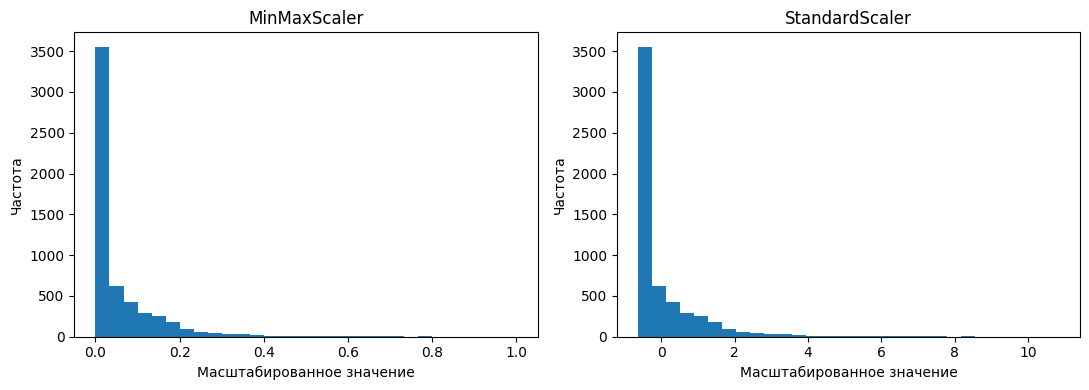

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(scale_example['MinMaxScaler'], bins=30)
axes[0].set_title('MinMaxScaler')
axes[0].set_xlabel('Масштабированное значение')
axes[0].set_ylabel('Частота')

axes[1].hist(scale_example['StandardScaler'], bins=30)
axes[1].set_title('StandardScaler')
axes[1].set_xlabel('Масштабированное значение')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Для итоговой матрицы используем `StandardScaler` для всех количественных показателей, кроме `year`. Год оставляем без масштабирования, так как это временной идентификатор, а не измеряемый экономический показатель.

In [12]:
# Убираем исходный текстовый код страны — его заменит one-hot представление
numeric_part = work.drop(columns=['country_code']).copy()

scale_cols = [c for c in numeric_part.select_dtypes(include=np.number).columns if c != 'year']
scaler = StandardScaler()

scaled_numeric = numeric_part.copy()
scaled_numeric[scale_cols] = scaler.fit_transform(numeric_part[scale_cols])

processed = pd.concat([
    scaled_numeric.reset_index(drop=True),
    country_encoded_df.reset_index(drop=True)
], axis=1)

print('Итоговый размер:', processed.shape)
print('Количество пропусков:', int(processed.isna().sum().sum()))
display(processed.head())

Итоговый размер: (5642, 233)
Количество пропусков: 0


,year,gdp_usd,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_rate_pct,labor_force_total,population_total,life_expectancy,trade_pct_gdp,exports_pct_gdp,imports_pct_gdp,current_account_pct_gdp,fdi_inflows_pct_gdp,internet_users_pct,...,country_code_URY,country_code_USA,country_code_UZB,country_code_VCT,country_code_VEN,country_code_VGB,country_code_VIR,country_code_VNM,country_code_VUT,country_code_WSM,country_code_XKX,country_code_YEM,country_code_ZAF,country_code_ZMB,country_code_ZWE
0,2000,-0.2092,0.7444,0.1860,-0.1163,-0.2910,-0.1889,-0.2520,0.2166,1.0739,1.1456,0.8973,1.0442,-0.2615,-0.7939,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2001,-0.2092,0.1457,0.1884,-0.1811,-0.2910,-0.1889,-0.2520,0.2288,0.9856,1.0294,0.8487,1.4562,-0.3901,-0.7388,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2002,-0.2092,-0.7462,0.2110,-0.1570,-0.2910,-0.1889,-0.2520,0.2394,0.8507,0.8090,0.8214,-1.1960,0.1602,-0.6824,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,2003,-0.2091,-0.3886,0.2366,-0.1379,-0.2910,-0.1889,-0.2520,0.2512,0.8425,0.7462,0.8738,-0.4668,-0.0018,-0.6160,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,2004,-0.2090,0.6871,0.3063,-0.2009,-0.2910,-0.1889,-0.2519,0.2497,0.8357,0.8125,0.7876,1.1197,-0.2236,-0.5430,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 6. Проверка результата и сохранение

In [13]:
checks = pd.Series({
    'Количество строк': processed.shape[0],
    'Количество признаков': processed.shape[1],
    'Пропусков': int(processed.isna().sum().sum()),
    'One-hot признаков стран': country_encoded_df.shape[1],
    'Масштабированных числовых признаков': len(scale_cols)
})
display(checks.to_frame('Значение'))

OUTPUT_PATH = Path('dataset_preprocessed.csv')
processed.to_csv(OUTPUT_PATH, index=False)
print('Подготовленный датасет сохранён:', OUTPUT_PATH.resolve())

,Значение
Количество строк,5642
Количество признаков,233
Пропусков,0
One-hot признаков стран,217
Масштабированных числовых признаков,15


Подготовленный датасет сохранён: /mnt/data/dataset_preprocessed.csv


## Вывод

В ходе лабораторной работы был выполнен полный цикл предварительной обработки данных:

1. Проанализированы типы признаков и пропуски.
2. Признак `real_interest_rate_pct` удалён из-за высокой доли пропусков (около 44%).
3. Остальные пропуски числовых признаков заполнены медианными значениями с помощью `SimpleImputer`.
4. Категориальный признак страны закодирован методом one-hot encoding.
5. Количественные признаки масштабированы с помощью `StandardScaler`; также продемонстрирован `MinMaxScaler`.
6. Получена итоговая матрица без пропусков, пригодная для последующего построения моделей машинного обучения.